#### Brain Tumor Classification using Pre-Trained Model - VGG-16

In [1]:
# Step 1 - Read the dataset

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

import cv2 as cv

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

In [2]:
train_dir = 'E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Training'
test_dir = 'E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Testing'

In [3]:
# Define a List for training and testing
X_train_list = [] 
y_train_list = []

In [4]:
# Class names

labels = os.listdir(train_dir)
print(labels)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [5]:
# Define the image size and batch size

img_size = (224,224) 
batch_size = 32

In [6]:
# Print the data path

for i in labels:
    path = os.path.join(train_dir, i)
    print(path)
 
print('-'*80)   
for i in labels:
    path = os.path.join(test_dir, i)
    print(path)

E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\pituitary_tumor
--------------------------------------------------------------------------------
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\pituitary_tumor


In [7]:
for iter in labels:
    path = os.path.join(train_dir,iter)
    for j in os.listdir(path):
        img = cv.imread(os.path.join(path,j))
        img = cv.resize(img, img_size)
        X_train_list.append(img)
        y_train_list.append(iter)

for iter in labels:
    path = os.path.join(test_dir,iter)
    for j in os.listdir(path):
        img = cv.imread(os.path.join(path,j))
        img = cv.resize(img,img_size)
        X_train_list.append(img)
        y_train_list.append(iter)
        
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

In [8]:
X_train.shape, y_train.shape

((3264, 224, 224, 3), (3264,))

In [9]:
# Shuffle the data

from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train, random_state=101)

In [10]:
X_train[0][0]

array([[  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [  2,   2,   2],
       [  3,   3,   3],
       [  3,   3,   3],
       [  1,   1,   1],
       [  2,   2,   2],
       [ 20,  20,  20],
       [ 47,  47,  47],
       [ 61,  61,  61],
       [ 57,  57,  57],
       [ 45,  45,  45],
       [ 30,  30,  30],
       [ 16,  16,  16],
       [ 16,  16,  16],
       [ 28,  28,  28],
       [ 53,  53,  53],
       [ 83,  83

In [11]:
y_train[0]

np.str_('no_tumor')

In [12]:
X_train  = np.array(X_train.astype('float32')) / 255.0

In [13]:
X_train[0]

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.15686275, 0.15686275, 0.15686275],
        [0.21960784, 0.21960784, 0.21960784],
        [0.26666668, 0

In [14]:
y_train_index = []
for i in y_train:
    y_train_index.append(labels.index(i))
y_train = y_train_index
y_train[0]


2

In [15]:
y_train = np.array(y_train)

In [16]:
print(type(X_train), X_train.shape, X_train.dtype)

<class 'numpy.ndarray'> (3264, 224, 224, 3) float32


In [17]:
print(type(y_train), y_train.shape, y_train.dtype)

<class 'numpy.ndarray'> (3264,) int64


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=101)
len(X_train),len(X_test),len(y_train),len(y_test)

(2611, 653, 2611, 653)

In [19]:
# Base model

base_model = tf.keras.applications.VGG16(input_shape = (img_size[0], img_size[1],3), weights = 'imagenet',include_top=False)
base_model.trainable = False
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
x = base_model.output
print(x)

<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>


In [21]:
# add a global spatial average pooling layer

x = base_model.output
x = GlobalAveragePooling2D()(x)

# let's add a fully-connected layer
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# and a logistic layer -- let's say we have 200 classes
predictions = Dense(4, activation='softmax')(x)

In [22]:
from keras.models import Model

In [23]:
# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

In [24]:
# Compile model
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
from tensorflow.keras.utils import to_categorical
# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

In [26]:
history = model.fit(X_train,y_train_cat, epochs = 25, batch_size = batch_size, validation_data=(X_test,y_test_cat))

Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.2728 - loss: 1.4310 - val_accuracy: 0.4916 - val_loss: 1.2960
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.3423 - loss: 1.3258 - val_accuracy: 0.5666 - val_loss: 1.2144
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.4358 - loss: 1.2466 - val_accuracy: 0.5957 - val_loss: 1.1215
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.5034 - loss: 1.1644 - val_accuracy: 0.6677 - val_loss: 1.0093
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.5499 - loss: 1.0828 - val_accuracy: 0.6646 - val_loss: 0.9339
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.6067 - loss: 0.9915 - val_accuracy: 0.7014 - val_loss: 0.8499
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.6346 - loss: 0.9274 - val_accuracy: 0.7366 - val_loss: 0.7843
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.6661 - loss: 0.8629 - val_accuracy: 0.6983 - v

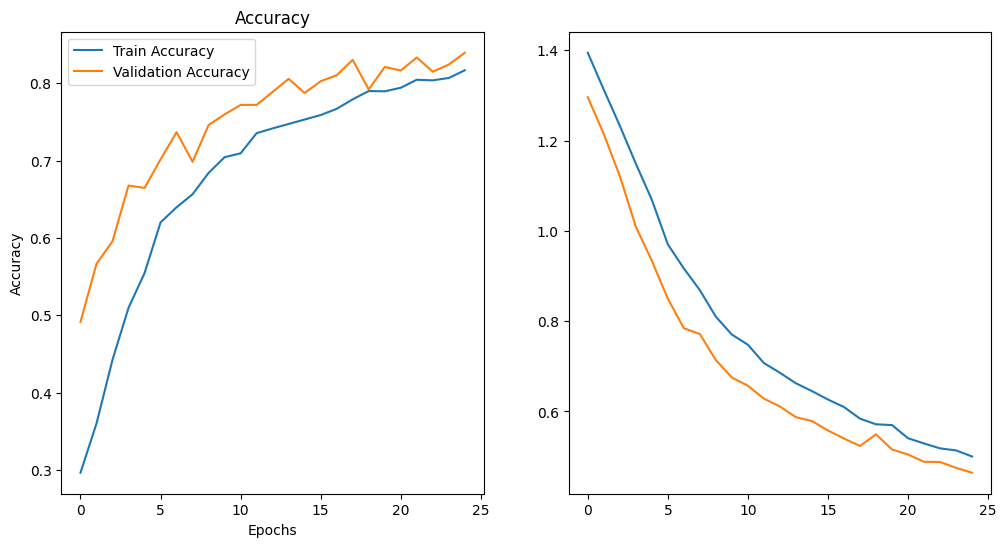

In [28]:
# Vizualizing the model performance

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.show()

In [29]:
y_pred = model.predict(X_test)
y_pred

21/21 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step


array([[1.2408780e-02, 1.4749745e-01, 2.3669729e-02, 8.1642407e-01],
       [4.0569842e-02, 3.9419357e-02, 9.0671998e-01, 1.3290781e-02],
       [3.2718718e-01, 6.4886415e-01, 5.7899202e-03, 1.8158728e-02],
       ...,
       [9.4595802e-04, 1.1795648e-02, 8.1498362e-03, 9.7910863e-01],
       [9.5542473e-01, 3.4723673e-02, 1.8349682e-03, 8.0166226e-03],
       [6.5667597e-03, 5.9718315e-02, 1.1569710e-02, 9.2214519e-01]],
      dtype=float32)

In [30]:
y_pred_class = np.argmax(y_pred, axis=1)
y_pred_class

array([3, 2, 1, 1, 3, 1, 2, 3, 1, 1, 2, 0, 0, 1, 1, 3, 3, 0, 3, 2, 3, 0,
       3, 1, 1, 3, 1, 3, 3, 1, 1, 3, 0, 1, 3, 2, 3, 2, 1, 2, 2, 3, 3, 1,
       1, 3, 0, 0, 3, 1, 2, 1, 3, 3, 2, 3, 0, 3, 1, 0, 1, 1, 1, 0, 3, 3,
       3, 0, 3, 0, 0, 0, 3, 1, 0, 2, 0, 2, 2, 1, 1, 2, 1, 3, 0, 0, 1, 1,
       2, 1, 1, 3, 1, 1, 0, 1, 0, 2, 3, 1, 1, 1, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 1, 3, 0, 3, 0, 3, 3, 2, 1, 0, 3, 3, 0, 3, 3, 1, 3, 3, 0, 1, 1,
       1, 3, 2, 2, 1, 3, 1, 1, 0, 1, 2, 0, 3, 1, 1, 1, 2, 2, 3, 1, 1, 3,
       2, 3, 1, 1, 2, 1, 3, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 3, 3, 1, 2, 1,
       1, 0, 3, 0, 3, 0, 1, 1, 3, 2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 1, 1, 0,
       3, 2, 3, 0, 3, 1, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 0, 3, 0, 0, 3, 0,
       2, 1, 3, 1, 3, 0, 3, 1, 3, 2, 0, 0, 3, 0, 0, 2, 3, 3, 0, 0, 3, 0,
       1, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 3, 1, 3, 3, 0, 3, 3, 1,
       1, 0, 0, 2, 0, 0, 0, 3, 3, 3, 0, 3, 1, 1, 0, 1, 2, 1, 3, 3, 3, 2,
       0, 1, 1, 0, 2, 1, 1, 3, 3, 2, 3, 0, 0, 3, 3,

In [33]:
y_test_class = np.argmax(y_test_cat, axis=1)

In [36]:
y_test_class

array([3, 2, 0, 1, 3, 1, 2, 3, 1, 1, 2, 0, 0, 1, 1, 3, 3, 2, 3, 2, 3, 0,
       1, 1, 1, 3, 0, 3, 3, 1, 1, 3, 0, 1, 3, 2, 3, 2, 0, 2, 2, 1, 3, 1,
       1, 3, 0, 1, 3, 0, 2, 0, 3, 3, 2, 3, 0, 3, 1, 0, 1, 1, 1, 0, 3, 3,
       3, 0, 2, 0, 0, 0, 3, 1, 0, 2, 0, 0, 2, 1, 1, 2, 3, 3, 0, 0, 1, 1,
       2, 1, 1, 3, 1, 1, 0, 1, 0, 2, 3, 1, 1, 0, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 0, 3, 0, 3, 0, 3, 3, 2, 1, 0, 1, 3, 0, 3, 3, 1, 3, 3, 0, 1, 0,
       1, 3, 2, 0, 1, 3, 1, 1, 1, 1, 2, 0, 1, 1, 0, 2, 2, 2, 3, 1, 1, 3,
       2, 3, 1, 1, 2, 0, 3, 2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 3, 3, 1, 2, 1,
       0, 0, 3, 0, 3, 0, 1, 0, 3, 2, 1, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 1,
       1, 2, 3, 0, 3, 1, 2, 3, 2, 1, 1, 2, 1, 1, 1, 0, 0, 3, 0, 0, 3, 0,
       2, 1, 3, 1, 3, 0, 1, 1, 3, 2, 0, 0, 3, 0, 0, 2, 3, 3, 0, 0, 3, 0,
       1, 2, 0, 0, 2, 1, 0, 2, 0, 0, 1, 0, 0, 0, 3, 1, 3, 3, 0, 3, 3, 1,
       0, 0, 0, 1, 2, 0, 0, 3, 3, 3, 0, 3, 1, 1, 0, 1, 2, 1, 3, 3, 1, 1,
       0, 1, 1, 0, 2, 0, 1, 3, 3, 2, 3, 0, 0, 3, 0,

Confusion Matric:
 [[127  34   5   2]
 [ 15 162   7  16]
 [  6  11  89   3]
 [  1   5   0 170]]




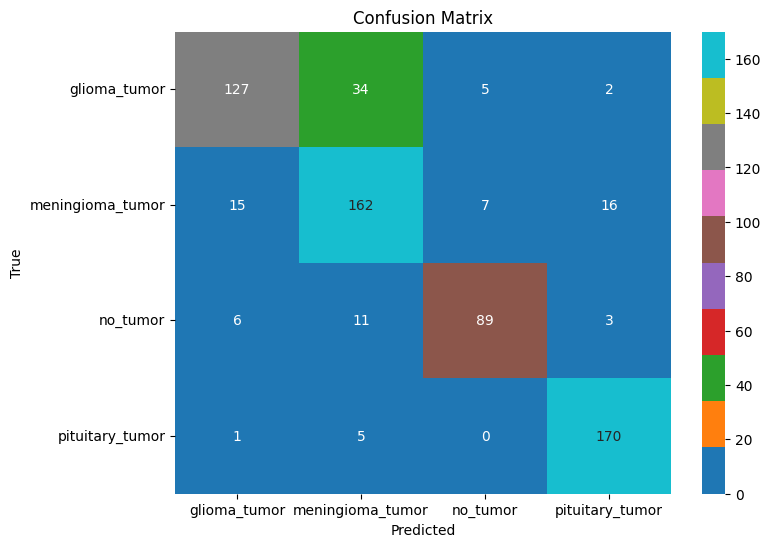

In [37]:
# Confusion Matrix

cm = confusion_matrix(y_test_class, y_pred_class)
print("Confusion Matric:\n", cm)

print('\n')

# Confusion Matrix with heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='tab10', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

(619, 495, 3)


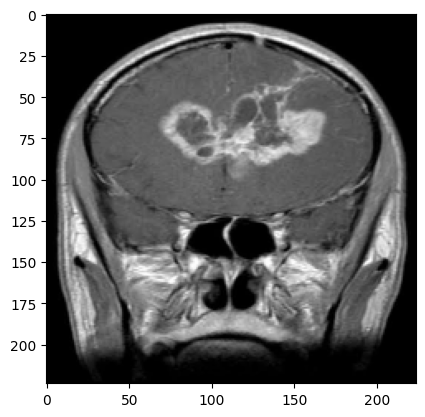

In [42]:
# Reading Image from directory
test_img = cv.imread("E:\\UCT Training AIMLDS\\GENAI_IITG_6Months\\brain_tumor_dataset\\Testing\\glioma_tumor\\image.jpg")
plt.imshow(test_img)
print(test_img.shape)

# Resize image
test_img = cv.resize(test_img,(224,224))
plt.imshow(test_img)
test_input = test_img.reshape(1,224,224,3)


In [43]:
# Predicting the image
pred = model.predict(test_input)
pred_class = np.argmax(pred, axis=1)
print(pred_class)
print(labels[pred_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
[0]
glioma_tumor
